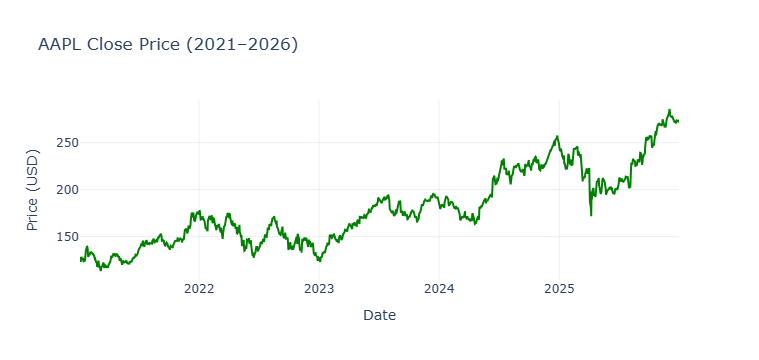

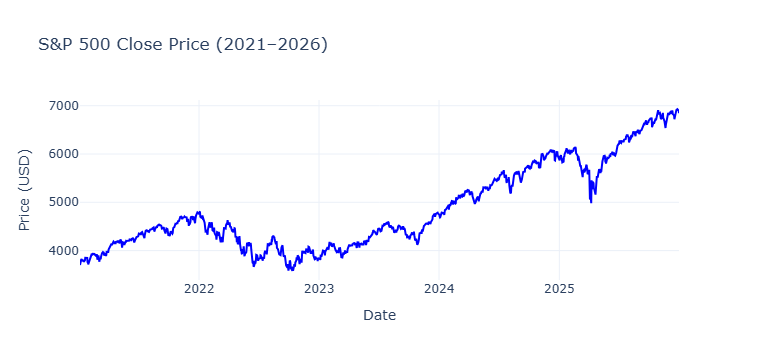

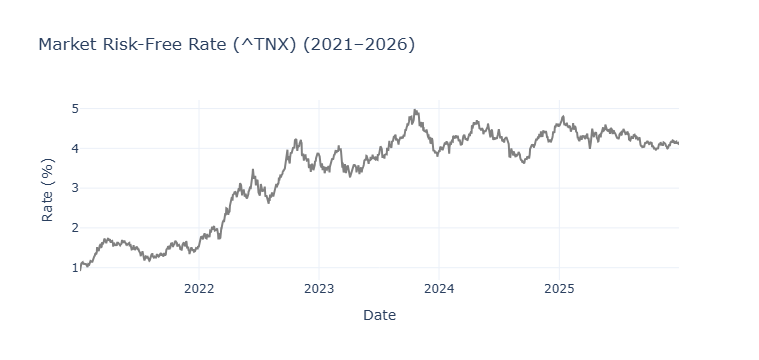

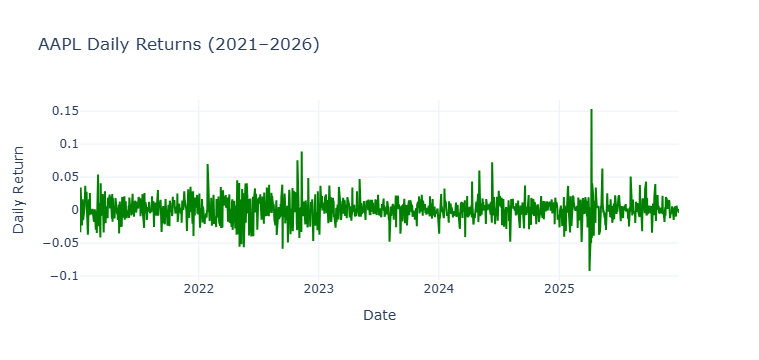

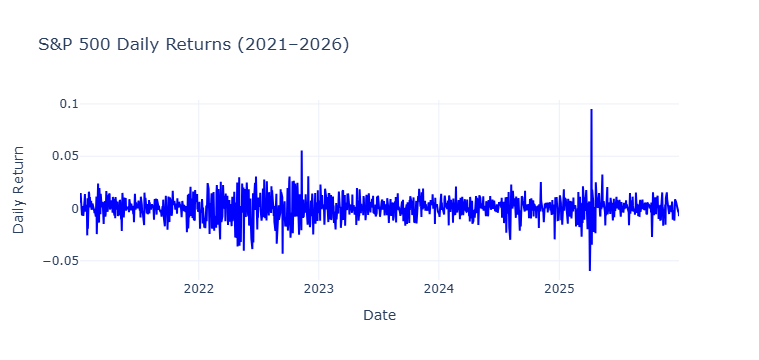

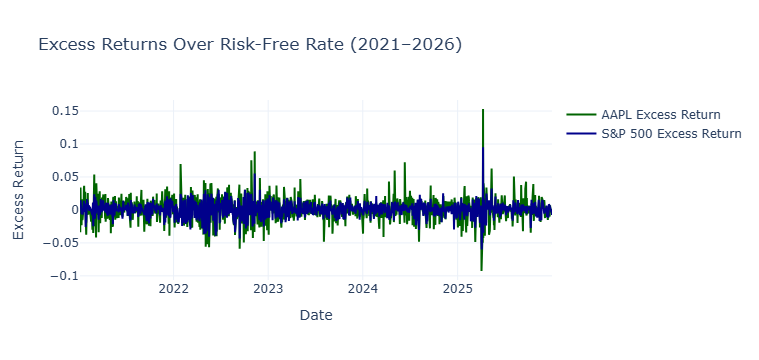

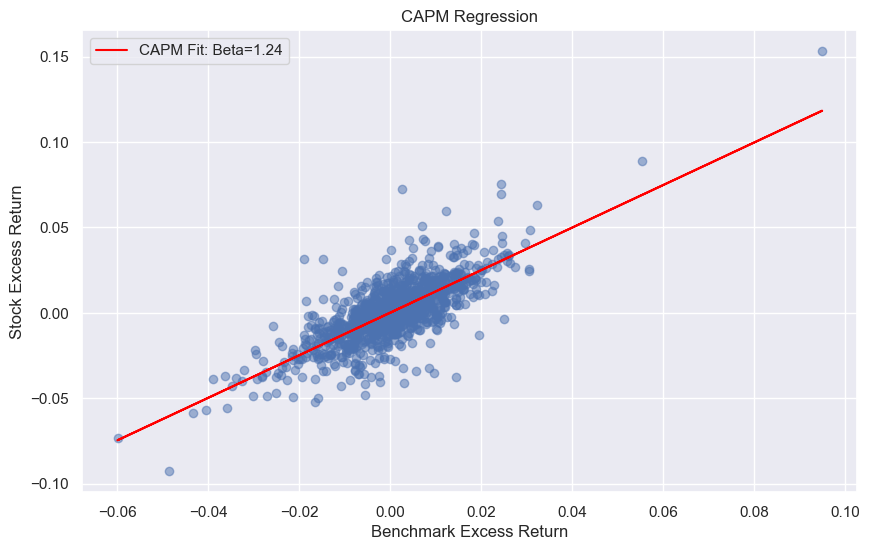

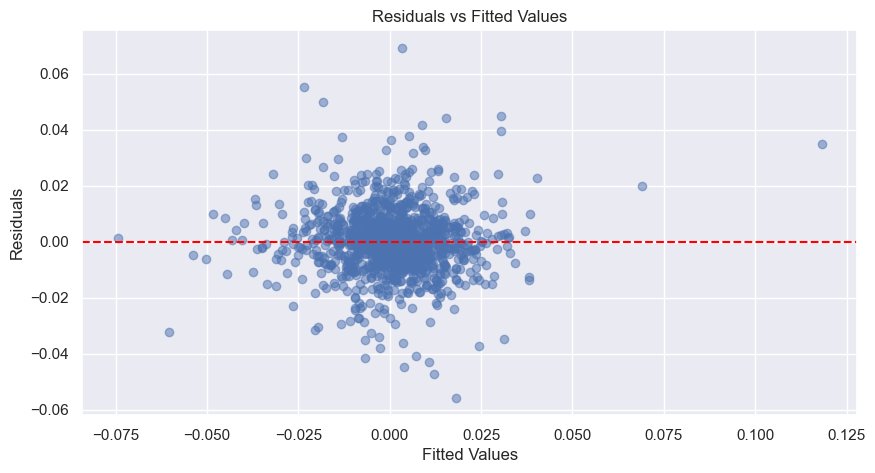

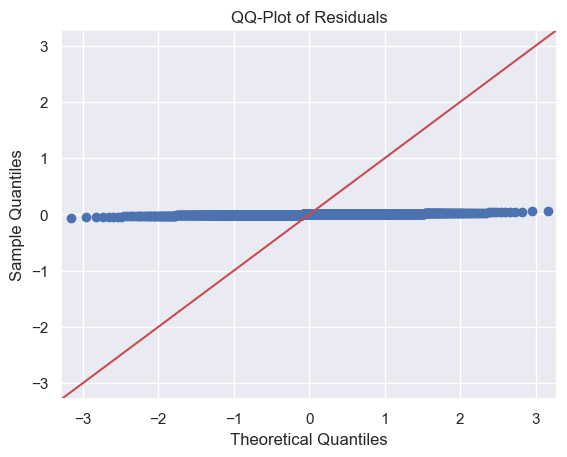

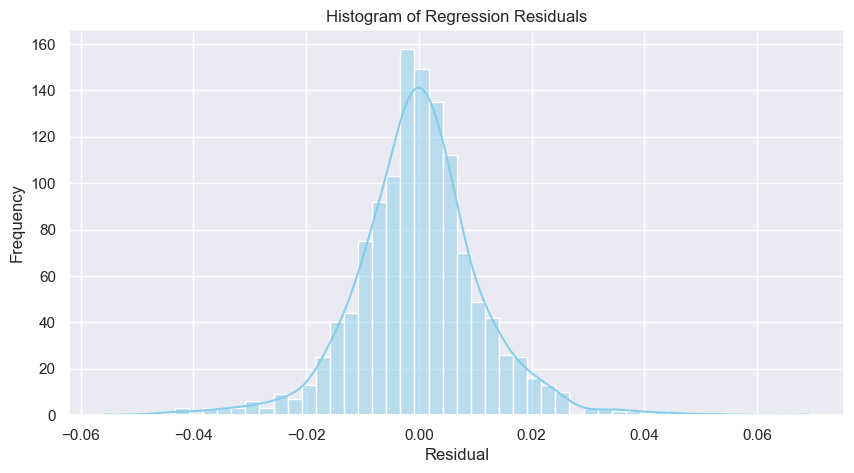

CAPM Beta: 1.2446
Expected Return (Annualized): 17.1712%
Sharpe Ratio: 1.2771
Durbin-Watson: 1.8298

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.574
Model:                            OLS   Adj. R-squared:                  0.573
Method:                 Least Squares   F-statistic:                     892.9
Date:                Tue, 24 Mar 2026   Prob (F-statistic):          1.51e-148
Time:                        11:11:25   Log-Likelihood:                 3825.3
No. Observations:                1254   AIC:                            -7647.
Df Residuals:                    1252   BIC:                            -7636.
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import statsmodels.api as sm
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import seaborn as sns

# User Inputs
stocks = ['AAPL']
rf_ticker = '^TNX'
benchmark = ['^GSPC']
start_date = '2021-01-01'
end_date = '2026-01-01'

# Download Data
def download_data(tickers, start, end):
    df = yf.download(tickers, start=start, end=end, progress=False)['Close']
    return df.dropna()

stock_prices = download_data(stocks, start_date, end_date)
benchmark_prices = download_data(benchmark, start_date, end_date)
rf_data = download_data(rf_ticker, start_date, end_date)

# Compute Returns
stock_ret = stock_prices.pct_change().dropna()
benchmark_ret = benchmark_prices.pct_change().dropna()

# Convert Risk-Free Rate to Daily Series
rf_daily = (rf_data / 100) / 252
rf_daily = rf_daily[rf_ticker].reindex(stock_ret.index).ffill()

# Compute Excess Returns
excess_stock = stock_ret['AAPL'] - rf_daily
excess_bench = benchmark_ret['^GSPC'] - rf_daily

# Plot Individual Prices
# AAPL Price
fig_aapl_price = go.Figure(go.Scatter(x=stock_prices.index, y=stock_prices['AAPL'],
                                      mode='lines', name='AAPL', line=dict(color='green')))
fig_aapl_price.update_layout(title='AAPL Close Price (2021–2026)',
                             xaxis_title='Date', yaxis_title='Price (USD)', template='plotly_white')
fig_aapl_price.show()

# Benchmark Price
fig_bench_price = go.Figure(go.Scatter(x=benchmark_prices.index, y=benchmark_prices['^GSPC'],
                                       mode='lines', name='S&P 500', line=dict(color='blue')))
fig_bench_price.update_layout(title='S&P 500 Close Price (2021–2026)',
                              xaxis_title='Date', yaxis_title='Price (USD)', template='plotly_white')
fig_bench_price.show()

# Risk-Free Rate
fig_rf_price = go.Figure(go.Scatter(x=rf_data.index, y=rf_data[rf_ticker],
                                   mode='lines', name='^TNX', line=dict(color='gray')))
fig_rf_price.update_layout(title='Market Risk-Free Rate (^TNX) (2021–2026)',
                           xaxis_title='Date', yaxis_title='Rate (%)', template='plotly_white')
fig_rf_price.show()

# Plot Individual Returns
# AAPL Daily Returns
fig_aapl_ret = go.Figure(go.Scatter(x=stock_ret.index, y=stock_ret['AAPL'],
                                   mode='lines', name='AAPL Daily Return', line=dict(color='green')))
fig_aapl_ret.update_layout(title='AAPL Daily Returns (2021–2026)',
                           xaxis_title='Date', yaxis_title='Daily Return', template='plotly_white')
fig_aapl_ret.show()

# Benchmark Daily Returns
fig_bench_ret = go.Figure(go.Scatter(x=benchmark_ret.index, y=benchmark_ret['^GSPC'],
                                     mode='lines', name='S&P 500 Daily Return', line=dict(color='blue')))
fig_bench_ret.update_layout(title='S&P 500 Daily Returns (2021–2026)',
                            xaxis_title='Date', yaxis_title='Daily Return', template='plotly_white')
fig_bench_ret.show()

# Excess Returns
fig_excess_ret = go.Figure()
fig_excess_ret.add_trace(go.Scatter(x=excess_stock.index, y=excess_stock,
                                    mode='lines', name='AAPL Excess Return', line=dict(color='darkgreen')))
fig_excess_ret.add_trace(go.Scatter(x=excess_bench.index, y=excess_bench,
                                    mode='lines', name='S&P 500 Excess Return', line=dict(color='darkblue')))
fig_excess_ret.update_layout(title='Excess Returns Over Risk-Free Rate (2021–2026)',
                             xaxis_title='Date', yaxis_title='Excess Return', template='plotly_white')
fig_excess_ret.show()

# CAPM Beta Estimation
cov_matrix = np.cov(excess_stock, excess_bench)
beta = cov_matrix[0,1] / cov_matrix[1,1]

X = sm.add_constant(excess_bench)
y = excess_stock
model = sm.OLS(y, X).fit(cov_type='HC3')
residuals = model.resid
dw_stat = sm.stats.durbin_watson(residuals)

# Statistical Plots
sns.set(style="darkgrid")

plt.figure(figsize=(10,6))
plt.scatter(excess_bench, excess_stock, alpha=0.5)
plt.plot(excess_bench, model.fittedvalues, color='red', label=f'CAPM Fit: Beta={beta:.2f}')
plt.xlabel('Benchmark Excess Return')
plt.ylabel('Stock Excess Return')
plt.title('CAPM Regression')
plt.legend()
plt.show()

plt.figure(figsize=(10,5))
plt.scatter(model.fittedvalues, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted Values')
plt.show()

sm.qqplot(residuals, line='45')
plt.title('QQ-Plot of Residuals')
plt.show()

plt.figure(figsize=(10,5))
sns.histplot(residuals, bins=50, kde=True, color='skyblue')
plt.title('Histogram of Regression Residuals')
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.show()

# Expected Return and Sharpe Ratio
rf_scalar = rf_daily.mean()
bench_scalar = benchmark_ret['^GSPC'].mean()

exp_ret = rf_scalar + beta * (bench_scalar * 252 - rf_scalar)
sharpe = (excess_stock.mean() * len(excess_stock)) / (excess_stock.std() * np.sqrt(len(excess_stock)))

# Summary Dictionary
summary = {
    'beta': beta,
    'expected_return': exp_ret,
    'sharpe_ratio': sharpe,
    'residuals': residuals,
    'durbin_watson': dw_stat,
    'regression_summary': model.summary()
}

# Display Metrics
print(f"CAPM Beta: {summary['beta']:.4f}")
print(f"Expected Return (Annualized): {summary['expected_return']:.4%}")
print(f"Sharpe Ratio: {summary['sharpe_ratio']:.4f}")
print(f"Durbin-Watson: {summary['durbin_watson']:.4f}\n")
print(summary['regression_summary'])

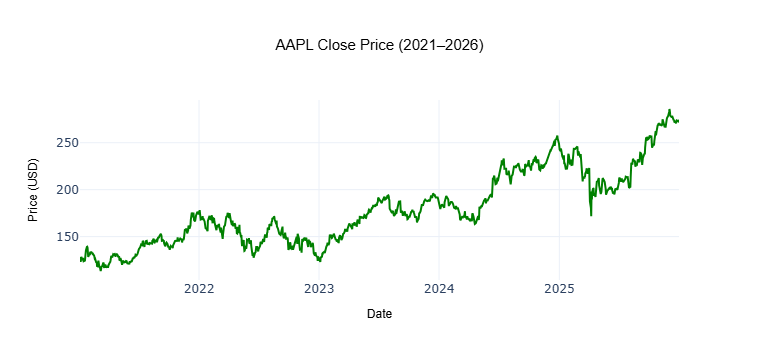

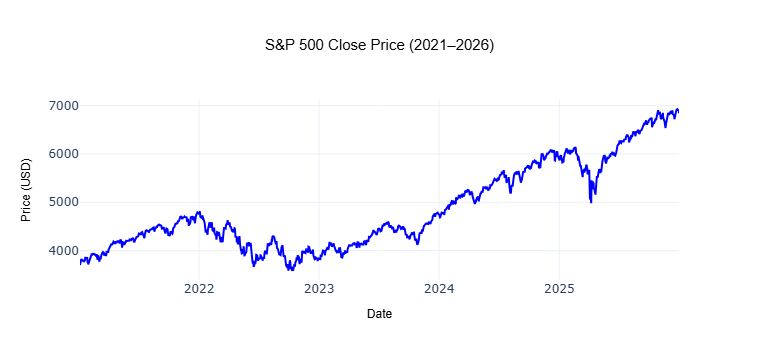

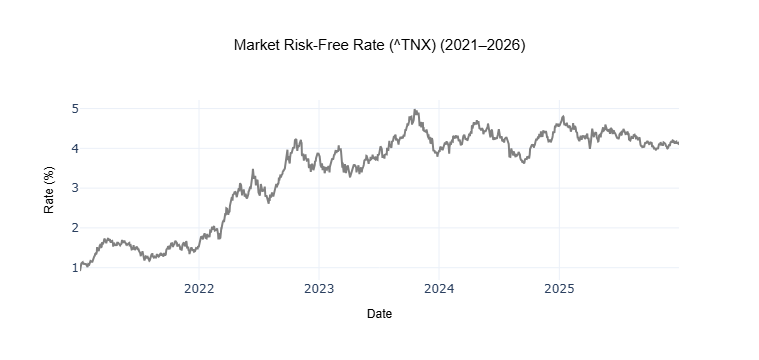

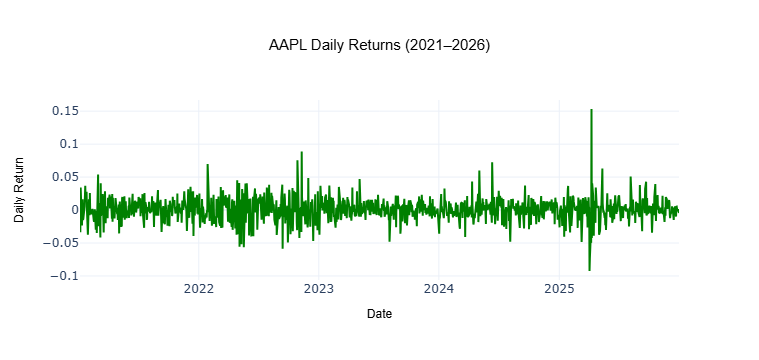

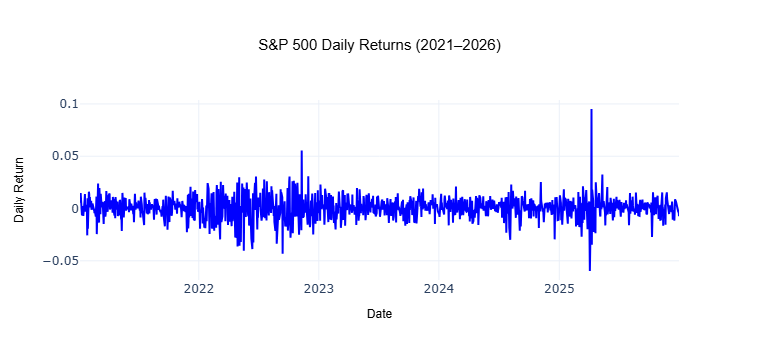

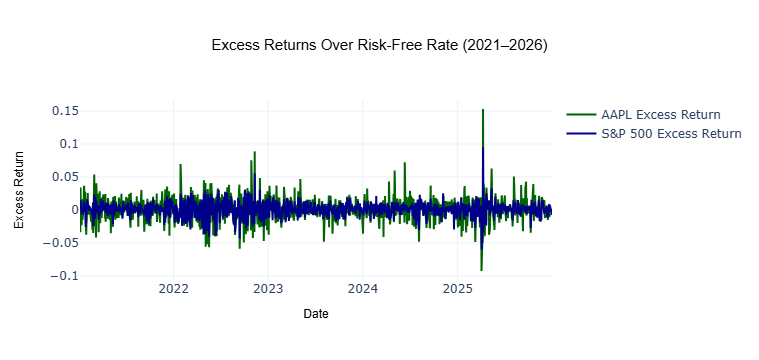

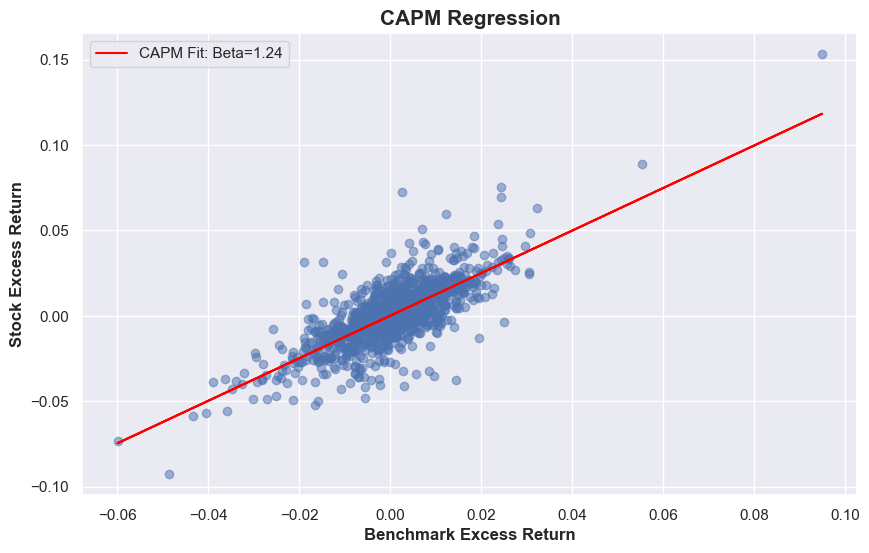

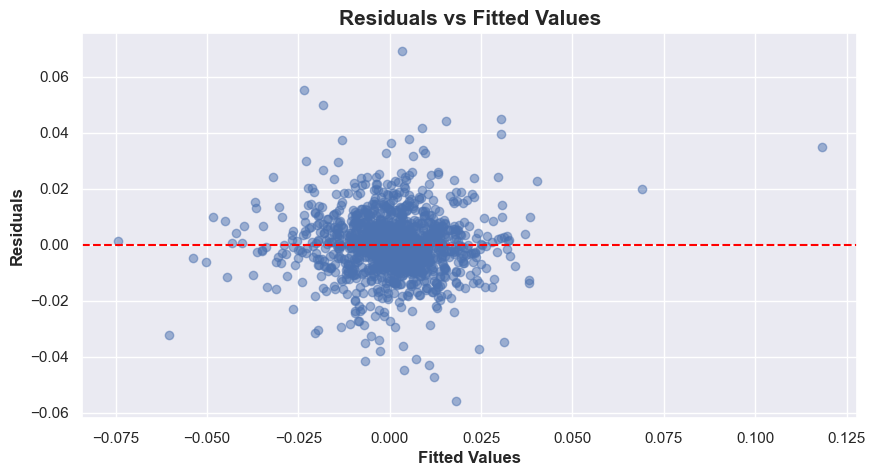

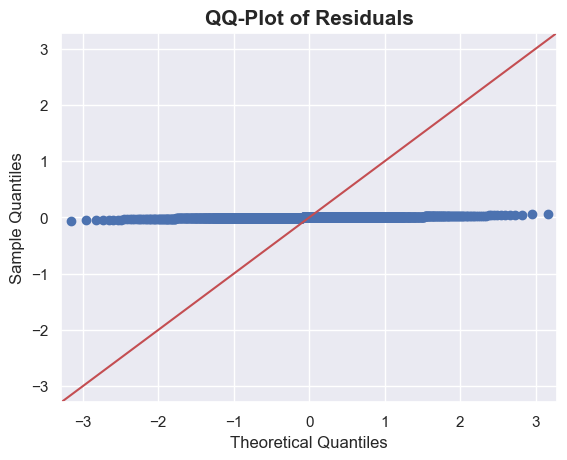

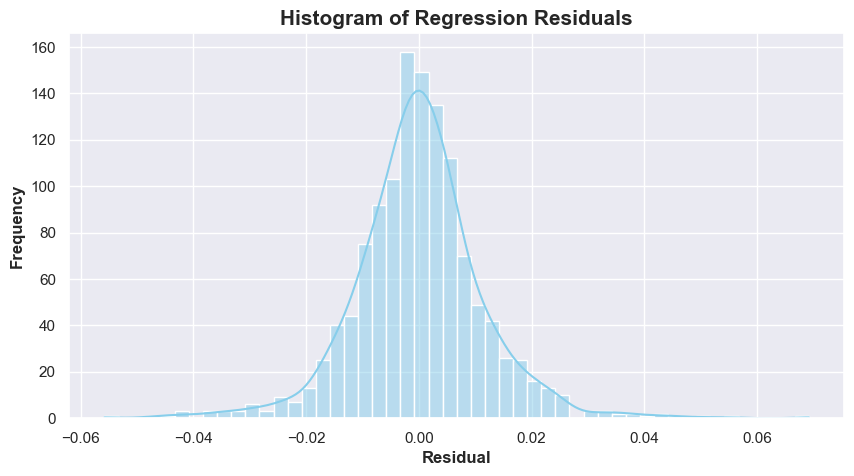

CAPM Beta: 1.2446
Expected Return (Annualized): 17.1712%
Sharpe Ratio: 1.2771
Durbin-Watson: 1.8298

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.574
Model:                            OLS   Adj. R-squared:                  0.573
Method:                 Least Squares   F-statistic:                     892.9
Date:                Tue, 24 Mar 2026   Prob (F-statistic):          1.51e-148
Time:                        11:22:35   Log-Likelihood:                 3825.3
No. Observations:                1254   AIC:                            -7647.
Df Residuals:                    1252   BIC:                            -7636.
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------

In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
import statsmodels.api as sm
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import seaborn as sns

# User Inputs
stocks = ['AAPL']
rf_ticker = '^TNX'
benchmark = ['^GSPC']
start_date = '2021-01-01'
end_date = '2026-01-01'

# Download Data
def download_data(tickers, start, end):
    df = yf.download(tickers, start=start, end=end, progress=False)['Close']
    return df.dropna()

stock_prices = download_data(stocks, start_date, end_date)
benchmark_prices = download_data(benchmark, start_date, end_date)
rf_data = download_data(rf_ticker, start_date, end_date)

# Compute Returns
stock_ret = stock_prices.pct_change().dropna()
benchmark_ret = benchmark_prices.pct_change().dropna()

# Convert Risk-Free Rate to Daily Series
rf_daily = (rf_data / 100) / 252
rf_daily = rf_daily[rf_ticker].reindex(stock_ret.index).ffill()

# Compute Excess Returns
excess_stock = stock_ret['AAPL'] - rf_daily
excess_bench = benchmark_ret['^GSPC'] - rf_daily

# Plot Individual Prices
# AAPL Price
fig_aapl_price = go.Figure(go.Scatter(x=stock_prices.index, y=stock_prices['AAPL'],
                                      mode='lines', name='AAPL', line=dict(color='green')))
fig_aapl_price.update_layout(
    title=dict(text='AAPL Close Price (2021–2026)', font=dict(size=15, family="Arial", color="black"), x=0.5),
    xaxis_title=dict(text='Date', font=dict(size=12, family="Arial", color="black")),
    yaxis_title=dict(text='Price (USD)', font=dict(size=12, family="Arial", color="black")),
    template='plotly_white'
)
fig_aapl_price.show()

# Benchmark Price
fig_bench_price = go.Figure(go.Scatter(x=benchmark_prices.index, y=benchmark_prices['^GSPC'],
                                       mode='lines', name='S&P 500', line=dict(color='blue')))
fig_bench_price.update_layout(
    title=dict(text='S&P 500 Close Price (2021–2026)', font=dict(size=15, family="Arial", color="black"), x=0.5),
    xaxis_title=dict(text='Date', font=dict(size=12, family="Arial", color="black")),
    yaxis_title=dict(text='Price (USD)', font=dict(size=12, family="Arial", color="black")),
    template='plotly_white'
)
fig_bench_price.show()

# Risk-Free Rate
fig_rf_price = go.Figure(go.Scatter(x=rf_data.index, y=rf_data[rf_ticker],
                                   mode='lines', name='^TNX', line=dict(color='gray')))
fig_rf_price.update_layout(
    title=dict(text='Market Risk-Free Rate (^TNX) (2021–2026)', font=dict(size=15, family="Arial", color="black"), x=0.5),
    xaxis_title=dict(text='Date', font=dict(size=12, family="Arial", color="black")),
    yaxis_title=dict(text='Rate (%)', font=dict(size=12, family="Arial", color="black")),
    template='plotly_white'
)
fig_rf_price.show()

# Plot Individual Returns
# AAPL Daily Returns
fig_aapl_ret = go.Figure(go.Scatter(x=stock_ret.index, y=stock_ret['AAPL'],
                                   mode='lines', name='AAPL Daily Return', line=dict(color='green')))
fig_aapl_ret.update_layout(
    title=dict(text='AAPL Daily Returns (2021–2026)', font=dict(size=15, family="Arial", color="black"), x=0.5),
    xaxis_title=dict(text='Date', font=dict(size=12, family="Arial", color="black")),
    yaxis_title=dict(text='Daily Return', font=dict(size=12, family="Arial", color="black")),
    template='plotly_white'
)
fig_aapl_ret.show()

# Benchmark Daily Returns
fig_bench_ret = go.Figure(go.Scatter(x=benchmark_ret.index, y=benchmark_ret['^GSPC'],
                                     mode='lines', name='S&P 500 Daily Return', line=dict(color='blue')))
fig_bench_ret.update_layout(
    title=dict(text='S&P 500 Daily Returns (2021–2026)', font=dict(size=15, family="Arial", color="black"), x=0.5),
    xaxis_title=dict(text='Date', font=dict(size=12, family="Arial", color="black")),
    yaxis_title=dict(text='Daily Return', font=dict(size=12, family="Arial", color="black")),
    template='plotly_white'
)
fig_bench_ret.show()

# Excess Returns
fig_excess_ret = go.Figure()
fig_excess_ret.add_trace(go.Scatter(x=excess_stock.index, y=excess_stock,
                                    mode='lines', name='AAPL Excess Return', line=dict(color='darkgreen')))
fig_excess_ret.add_trace(go.Scatter(x=excess_bench.index, y=excess_bench,
                                    mode='lines', name='S&P 500 Excess Return', line=dict(color='darkblue')))
fig_excess_ret.update_layout(
    title=dict(text='Excess Returns Over Risk-Free Rate (2021–2026)', font=dict(size=15, family="Arial", color="black"), x=0.5),
    xaxis_title=dict(text='Date', font=dict(size=12, family="Arial", color="black")),
    yaxis_title=dict(text='Excess Return', font=dict(size=12, family="Arial", color="black")),
    template='plotly_white'
)
fig_excess_ret.show()

# CAPM Beta Estimation
cov_matrix = np.cov(excess_stock, excess_bench)
beta = cov_matrix[0,1] / cov_matrix[1,1]

X = sm.add_constant(excess_bench)
y = excess_stock
model = sm.OLS(y, X).fit(cov_type='HC3')
residuals = model.resid
dw_stat = sm.stats.durbin_watson(residuals)

# Statistical Plots
sns.set(style="darkgrid")

plt.figure(figsize=(10,6))
plt.scatter(excess_bench, excess_stock, alpha=0.5)
plt.plot(excess_bench, model.fittedvalues, color='red', label=f'CAPM Fit: Beta={beta:.2f}')
plt.xlabel('Benchmark Excess Return', fontsize=12, fontweight='bold')
plt.ylabel('Stock Excess Return', fontsize=12, fontweight='bold')
plt.title('CAPM Regression', fontsize=15, fontweight='bold', loc='center')
plt.legend()
plt.show()

plt.figure(figsize=(10,5))
plt.scatter(model.fittedvalues, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted Values', fontsize=12, fontweight='bold')
plt.ylabel('Residuals', fontsize=12, fontweight='bold')
plt.title('Residuals vs Fitted Values', fontsize=15, fontweight='bold', loc='center')
plt.show()

sm.qqplot(residuals, line='45')
plt.title('QQ-Plot of Residuals', fontsize=15, fontweight='bold', loc='center')
plt.show()

plt.figure(figsize=(10,5))
sns.histplot(residuals, bins=50, kde=True, color='skyblue')
plt.title('Histogram of Regression Residuals', fontsize=15, fontweight='bold', loc='center')
plt.xlabel('Residual', fontsize=12, fontweight='bold')
plt.ylabel('Frequency', fontsize=12, fontweight='bold')
plt.show()

# Expected Return and Sharpe Ratio
rf_scalar = rf_daily.mean()
bench_scalar = benchmark_ret['^GSPC'].mean()

exp_ret = rf_scalar + beta * (bench_scalar * 252 - rf_scalar)
sharpe = (excess_stock.mean() * len(excess_stock)) / (excess_stock.std() * np.sqrt(len(excess_stock)))

# Summary Dictionary
summary = {
    'beta': beta,
    'expected_return': exp_ret,
    'sharpe_ratio': sharpe,
    'residuals': residuals,
    'durbin_watson': dw_stat,
    'regression_summary': model.summary()
}

# Display Metrics
print(f"CAPM Beta: {summary['beta']:.4f}")
print(f"Expected Return (Annualized): {summary['expected_return']:.4%}")
print(f"Sharpe Ratio: {summary['sharpe_ratio']:.4f}")
print(f"Durbin-Watson: {summary['durbin_watson']:.4f}\n")
print(summary['regression_summary'])